# Business Objective

The goal of this project is to build an **Enterprise Customer Intelligence Platform** using the Olist e-commerce dataset.

The platform aims to answer critical business questions, including:

- How is the business performing over time?
- Who are the most valuable customers?
- Which product categories drive the highest revenue?
- Which sellers perform best?
- How efficient is the delivery process?
- What factors influence customer satisfaction?
- How can customer behavior be leveraged for predictive analytics such as segmentation and customer lifetime value?

The insights generated throughout this project will support data-driven business decision-making and serve as the foundation for subsequent machine learning models.

In [1]:
# =====================================
# Import Required Libraries
# =====================================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.express as px

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [4]:
# =====================================
# Define Project Paths
# =====================================

PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "datasets" / "Olist"

print(DATA_DIR)

c:\Users\swastik\Desktop\customer_intelligence_platform\datasets\Olist


In [5]:
# =====================================
# Load Olist Dataset
# =====================================

customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")

orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")

order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")

payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")

reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")

products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")

sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")

geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")

translation = pd.read_csv(
    DATA_DIR / "product_category_name_translation.csv"
)

In [6]:
# managing datasets in a dictionary for easy access
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Translation": translation
}

In [7]:
overview=[] 
for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

In [8]:
overview

[{'Dataset': 'Customers',
  'Rows': 99441,
  'Columns': 5,
  'Missing Values': np.int64(0),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Orders',
  'Rows': 99441,
  'Columns': 8,
  'Missing Values': np.int64(4908),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Order Items',
  'Rows': 112650,
  'Columns': 7,
  'Missing Values': np.int64(0),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Payments',
  'Rows': 103886,
  'Columns': 5,
  'Missing Values': np.int64(0),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Reviews',
  'Rows': 99224,
  'Columns': 7,
  'Missing Values': np.int64(145903),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Products',
  'Rows': 32951,
  'Columns': 9,
  'Missing Values': np.int64(2448),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Sellers',
  'Rows': 3095,
  'Columns': 4,
  'Missing Values': np.int64(0),
  'Duplicate Rows': np.int64(0)},
 {'Dataset': 'Geolocation',
  'Rows': 1000163,
  'Columns': 5,
  'Missing Values': np.int64(0),
  'Duplicate Rows

In [9]:
for name, df in datasets.items():
    print("="*80)
    print(name.upper())
    print("="*80)

    display(df.head())

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


ORDER ITEMS


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
missing_summary = []

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) == 0:
        continue

    temp = pd.DataFrame({
        "Dataset": name,
        "Column": missing.index,
        "Missing Values": missing.values,
        "Missing Percentage": (missing.values / len(df) * 100).round(2)
    })

    missing_summary.append(temp)

# Combine all DataFrames after the loop
missing_summary = pd.concat(missing_summary, ignore_index=True)

# Sort
missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Dataset,Column,Missing Values,Missing Percentage
3,Reviews,review_comment_title,87656,88.34
4,Reviews,review_comment_message,58247,58.70
2,Orders,order_delivered_customer_date,2965,2.98
6,Products,product_name_lenght,610,1.85
5,Products,product_category_name,610,1.85
7,Products,product_description_lenght,610,1.85
8,Products,product_photos_qty,610,1.85
1,Orders,order_delivered_carrier_date,1783,1.79
0,Orders,order_approved_at,160,0.16
9,Products,product_weight_g,2,0.01


In [11]:
import plotly.io as pio

pio.renderers.default = "plotly_mimetype"

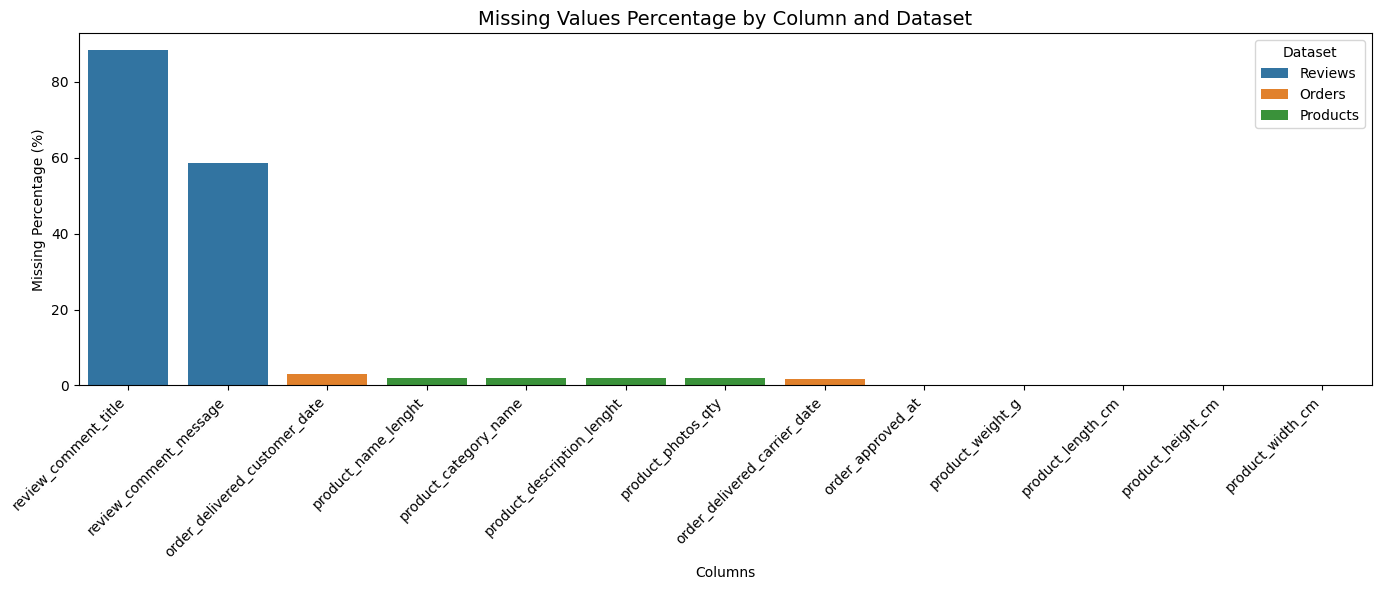

In [12]:
if not missing_summary.empty:
    plt.figure(figsize=(14, 6))

    sns.barplot(
        data=missing_summary,
        x="Column",
        y="Missing Percentage",
        hue="Dataset"
    )

    plt.title("Missing Values Percentage by Column and Dataset", fontsize=14)
    plt.xlabel("Columns")
    plt.ylabel("Missing Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Dataset")
    plt.tight_layout()

    plt.show()

In [13]:
# duplicate row analysis 
duplicate_summary = []
for name, df in datasets.items():
    duplicate_summary.append({
        "Dataset": name,
        "Duplicate Rows": df.duplicated().sum(),
        "Percentage": round(df.duplicated().sum() / len(df) * 100, 2)
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)
duplicate_summary_df

,Dataset,Duplicate Rows,Percentage
0,Customers,0,0.00
1,Orders,0,0.00
2,Order Items,0,0.00
3,Payments,0,0.00
4,Reviews,0,0.00
5,Products,0,0.00
6,Sellers,0,0.00
7,Geolocation,261831,26.18
8,Translation,0,0.00


In [14]:
# checking for duplicate primary keys 
primary_keys={
    "Customers":"customer_id",
    "Orders": "order_id",
    "Products":"product_id",
    "Sellers": "seller_id"
}

for dataset, key in primary_keys.items():
    df = datasets[dataset]
    duplicate_count = df.duplicated(subset=[key]).sum()
    percentage = (duplicate_count / len(df)) * 100

    print(f"Dataset: {dataset}")
    print(f"Primary Key: {key}")
    print(f"Duplicate Count: {duplicate_count}")
    print(f"Percentage of Duplicates: {percentage:.2f}%")
    print("="*50)

Dataset: Customers
Primary Key: customer_id
Duplicate Count: 0
Percentage of Duplicates: 0.00%
Dataset: Orders
Primary Key: order_id
Duplicate Count: 0
Percentage of Duplicates: 0.00%
Dataset: Products
Primary Key: product_id
Duplicate Count: 0
Percentage of Duplicates: 0.00%
Dataset: Sellers
Primary Key: seller_id
Duplicate Count: 0
Percentage of Duplicates: 0.00%


In [15]:
# getting unique values 
for name, df in datasets.items():
    print("="*80)
    print(name.upper())
    print("="*80)

    unique_values = df.nunique()
    unique_df = pd.DataFrame({
        "Column": unique_values.index,
        "Unique Values": unique_values.values
    })

    display(unique_df)

CUSTOMERS


,Column,Unique Values
0,customer_id,99441
1,customer_unique_id,96096
2,customer_zip_code_prefix,14994
3,customer_city,4119
4,customer_state,27


ORDERS


,Column,Unique Values
0,order_id,99441
1,customer_id,99441
2,order_status,8
3,order_purchase_timestamp,98875
4,order_approved_at,90733
5,order_delivered_carrier_date,81018
6,order_delivered_customer_date,95664
7,order_estimated_delivery_date,459


ORDER ITEMS


...

,Column,Unique Values
0,seller_id,3095
1,seller_zip_code_prefix,2246
2,seller_city,611
3,seller_state,23


GEOLOCATION


,Column,Unique Values
0,geolocation_zip_code_prefix,19015
1,geolocation_lat,717360
2,geolocation_lng,717613
3,geolocation_city,8011
4,geolocation_state,27


TRANSLATION


,Column,Unique Values
0,product_category_name,71
1,product_category_name_english,71


In [16]:
for name, df in datasets.items():
    print("="*80)
    print(name)
    print("="*80)
    display(df.describe(include="all").T)

Customers


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,"99,441.00",NaN,NaN,NaN,"35,137.47","29,797.94","1,003.00","11,347.00","24,416.00","58,900.00","99,990.00"
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Orders


,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-03-31 15:08:21,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


Order Items


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,"3,095.00",NaN,NaN,NaN,"32,291.06","32,713.45","1,001.00","7,093.50","14,940.00","64,552.50","99,730.00"
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Geolocation


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,"1,000,163.00",NaN,NaN,NaN,"36,574.17","30,549.34","1,001.00","11,075.00","26,530.00","63,504.00","99,990.00"
geolocation_lat,"1,000,163.00",NaN,NaN,NaN,-21.18,5.72,-36.61,-23.60,-22.92,-19.98,45.07
geolocation_lng,"1,000,163.00",NaN,NaN,NaN,-46.39,4.27,-101.47,-48.57,-46.64,-43.77,121.11
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Translation


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


In [17]:
date_columns= [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for column in date_columns:
    if column in orders.columns:
        orders[column] = pd.to_datetime(orders[column], errors="coerce")

In [18]:
# checking referential integrity between datasets 
# orders -> customers 
invalid_customers = (~orders["customer_id"].isin(customers["customer_id"])).sum()

# order items -> orders 
invalid_orders = (~order_items["order_id"].isin(orders["order_id"])).sum()




## Observations

- The Olist dataset consists of **9 interconnected relational tables** covering customers, orders, products, sellers, payments, reviews, and geolocation data.
- The largest table is **Geolocation** with over **1 million records**, while the smallest table is the **Product Category Translation** table with **71 records**.
- The **Orders** and **Customers** tables each contain **99,441 records**, indicating a one-to-one mapping between orders and customer entries.
- The dataset is structured similarly to a relational database, making it suitable for SQL-style joins and business analytics.

## Observations

- Most datasets are highly complete with very few missing values.
- The **Reviews** dataset has the largest number of missing values.
    - `review_comment_title` has **88.34% missing values**.
    - `review_comment_message` has **58.70% missing values**.
- These missing review comments are expected because many customers leave only a rating without a written review.
- The **Orders** dataset contains a small percentage of missing delivery-related timestamps.
    - `order_delivered_customer_date` has **2.98% missing values**.
    - `order_delivered_carrier_date` has **1.79% missing values**.
    - `order_approved_at` has only **0.16% missing values**.
- The **Products** dataset contains approximately **1.85% missing values** in product metadata such as category name, description length, and photo count.
- Overall, the missing data appears limited and manageable without significantly affecting downstream analysis.

## Observations

- All datasets except the Geolocation table contain **zero duplicate rows**.
- The **Geolocation** dataset contains **261,831 duplicate rows (26.18%)**.
- Duplicate geolocation entries are expected because multiple customers and sellers can share the same ZIP code.
- These duplicates should not be removed blindly, as they may represent legitimate geographic mappings.

## Observations

- Primary key validation confirms that all major entity tables have **unique identifiers**.
- No duplicate values were found in:
    - customer_id
    - order_id
    - product_id
    - seller_id
- This indicates that the relational structure of the dataset is well maintained and suitable for joins across multiple tables.

## Observations

- Customer information consists mainly of location attributes rather than personal demographics.
- Orders contain purchase timestamps and delivery lifecycle information.
- Payments store transaction values and payment methods.
- Products provide product metadata and category information.
- Reviews capture customer satisfaction through ratings and optional review comments.
- Sellers represent marketplace vendors responsible for fulfilling customer orders.

## Observations

- All order-related timestamp columns were successfully converted to datetime format.
- This enables future time-series analyses such as:
    - Monthly revenue trends
    - Delivery time analysis
    - Customer recency calculations
    - Seasonal sales patterns

## Observations

- Referential integrity checks indicate that foreign key relationships between the tables are consistent.
- Every customer referenced in the Orders table exists in the Customers table.
- Every order referenced in the Order Items table exists in the Orders table.
- This confirms that the dataset can be safely joined without introducing orphan records.

# Conclusion

The Olist dataset is a well-structured relational e-commerce dataset consisting of multiple interconnected tables representing customers, orders, products, sellers, payments, reviews, and geographic information.

Data quality assessment indicates that:

- The majority of tables contain no duplicate records.
- Primary keys are unique across all major entities.
- Missing values are limited and primarily concentrated in optional review text fields.
- Product metadata contains a small amount of missing information that can be handled during preprocessing.
- Date columns have been standardized for temporal analysis.
- Overall, the dataset is sufficiently clean and suitable for advanced analytics, feature engineering, and machine learning tasks.

The next stage of the project will focus on **business-oriented exploratory analysis**, beginning with executive KPIs such as revenue, customer growth, order trends, and payment analysis.